In [ ]:
#%%

# %load_ext autoreload
# %autoreload 2

import os
os.environ["CUDA_VISIBLE_DEVICES"] = '0'

from selfmod import *

import umap


############# Contextual Self-Modulation #############

Jax version: 0.4.35
Available devices: [CudaDevice(id=0)]


In [ ]:
#%%

## For reproducibility
seed = 2024

## Dataloader hps
ode_count = 10          ## Total number of ODEs in the dataset
nb_experts = 8
top_k = 6

num_envs = (16*ode_count, 16*ode_count)
num_shots = (-1, -1)
num_workers = 0
shuffle = False
train_proportion = 0.4  ## Min proporrion of the trajectory for training
test_proportion = 1.0

## Learner/model hps
context_pool_size = 4
context_size = 64
taylor_orders = (2, 0)
# ivp_args = {"return_traj":True, "max_steps":256*2, "dt_min":1e-4, "integrator":diffrax.Tsit5()}
ivp_args = {"return_traj":True, "max_steps":256*16, "dt_init":1e-2, "integrator":diffrax.Tsit5(), "rtol": 1e-3, "atol":1e-6, "clip_sol":None, "adjoint": diffrax.RecursiveCheckpointAdjoint()}
skip_steps = 4
# loss_contributors = 16*5//2
loss_contributors = 16*ode_count
max_ret_env_states = num_envs[0]

## Train and adapt hps
init_lrs = (5e-4, 5e-4)
sched_factor = 0.2
max_train_batches = 1
max_adapt_batches = 1

proximal_betas = (0., 10., 0.)

nb_outer_steps = 8000
nb_inner_steps = (1, 1, 1)
nb_adapt_epochs = 5000
validate_every = 400*1

print_error_every = (100*1, 100*1)

meta_train = False
save_trainer = True
meta_test = True

run_folder = "./"
# run_folder = None
data_folder = "./data_2D/"

In [ ]:
#%%

if run_folder==None:
    run_folder = make_run_folder('./runs/')
else:
    print("Using existing run folder:", run_folder)

adapt_folder = setup_run_folder(run_folder, os.path.basename(__file__))

Using existing run folder: ./
Completed copied scripts 


cp: 'main_ncf_experts.py' and './main_ncf_experts.py' are the same file
cp: '/lus/lfs1aip1/home/benchmarking/ddrous.benchmarking/Projects/Self-Mod/examples/foundational/runs/241107-162020-SuperGolden/selfmod' and './selfmod' are the same file


In [ ]:
#%%

## Define 4 keys for dataloader(s), learner(s), trainer(s) and visualtester(s)
mother_key = jax.random.PRNGKey(seed)
data_key, model_key, trainer_key, test_key = jax.random.split(mother_key, num=4)

train_dataloader = NumpyLoader(ODEBenchDataset(data_dir=data_folder+"train.npz", 
                                            #    norm_consts=data_folder+"train_bounds.npy",   ## since more data in test/val sets
                                               num_shots=num_shots[0], 
                                               skip_steps=skip_steps, 
                                               traj_prop_min=train_proportion), 
                              batch_size=num_envs[0],
                              shuffle=shuffle,
                              num_workers=num_workers,
                              drop_last=False)

val_dataloader = NumpyLoader(ODEBenchDataset(data_dir=data_folder+"test.npz", 
                                            #  norm_consts=data_folder+"train_bounds.npy",
                                             num_shots=num_shots[1], 
                                             skip_steps=skip_steps,
                                             traj_prop_min=test_proportion),
                              batch_size=num_envs[0],
                              shuffle=shuffle,
                              num_workers=num_workers,
                              drop_last=False)

In [ ]:
#%%

# ## Define model and loss function for the learner
class Expert(eqx.Module):
    layers_data: list
    activations_data: list
    layers_main: list
    layers_ctx: list
    activations_main: list
    activations_ctx: list

    ctx_utils:any
    depth_data:int
    depth_main:int

    rescaler: eqx.Module

    def __init__(self, data_size, hidden_size, depth_data, depth_main, context_size, ctx_utils=None, key=None):
        self.ctx_utils = ctx_utils
        self.depth_data = depth_data
        self.depth_main = depth_main
        depth_ctx = depth_data

        layer_ctx_size = hidden_size
        # layer_ctx_size = context_size//depth_main  ## Size of the context to modulate each shared/main layer
        # assert context_size%depth_main==0, "Context size must be divisible by the depth of the main network"
        total_ctx_size = layer_ctx_size * depth_main


        keys_ctx = jax.random.split(key, num=depth_ctx+1)
        hid_ctx_size = (context_size + total_ctx_size) // 2
        self.activations_ctx = [Swish(key=k) for k in keys_ctx[:depth_ctx]]
        self.layers_ctx = [eqx.nn.Linear(context_size, hid_ctx_size, key=keys_ctx[0])]
        self.layers_ctx += [eqx.nn.Linear(hid_ctx_size, hid_ctx_size, key=keys_ctx[i]) for i in range(1, depth_ctx)]
        self.layers_ctx += [eqx.nn.Linear(hid_ctx_size, total_ctx_size, key=keys_ctx[depth_ctx])]

        keys = jax.random.split(key, num=depth_data+depth_main+2)
        self.activations_data = [Swish(key=k) for k in keys[:depth_data]]
        self.layers_data = [eqx.nn.Linear(0+data_size, hidden_size, key=keys[0])]
        self.layers_data += [eqx.nn.Linear(hidden_size, hidden_size, key=keys[i]) for i in range(1, depth_data)]
        self.layers_data += [eqx.nn.Linear(hidden_size, layer_ctx_size, key=keys[depth_data])]

        self.activations_main = [Swish(key=k) for k in keys[depth_data+2:]]
        self.layers_main = [eqx.nn.Linear(2*layer_ctx_size, hidden_size, key=keys[depth_data+1])]
        self.layers_main += [eqx.nn.Linear(hidden_size+layer_ctx_size, hidden_size, key=keys[depth_data+i+1]) for i in range(1, depth_main)]
        self.layers_main += [eqx.nn.Linear(hidden_size, data_size, key=keys[depth_data+depth_main+1])]

        assert len(self.layers_data) == len(self.activations_data)+1, f"Total number of layers {len(self.layers_data)} and activations {len(self.activations_data)} mismatch in the data network"
        assert len(self.layers_main) == len(self.activations_main)+1, f"Total number of layers {len(self.layers_main)} and activations {len(self.activations_main)} mismatch in the main network"

        self.rescaler = eqx.nn.Linear(context_size, 1, key=keys[depth_data+depth_main+2])

    def __call__(self, in_dat):
        t, y, ctx = in_dat

        ## Rescale factor
        factor = jnp.clip(jax.nn.relu(self.rescaler(ctx).squeeze()), 1, 1e2)
        y = y / factor

        for layer, activation in zip(self.layers_ctx[:-1], self.activations_ctx):
            ctx = activation(layer(ctx))
        ctx = self.layers_ctx[-1](ctx)

        ## Split the context into parts for each layer
        ctx_parts = jnp.split(ctx[:], self.depth_main, axis=0)

        # y = jnp.concatenate([t_arr, y], axis=0)
        for layer, activation in zip(self.layers_data[:-1], self.activations_data):
            y = activation(layer(y))
        y = self.layers_data[-1](y)

        ## Apply the context at each layer (except the very last)
        for layer, activation, ctx_part in zip(self.layers_main[:-1], self.activations_main, ctx_parts):
            y = jnp.concatenate([y, ctx_part], axis=0)
            y = activation(layer(y))
        y = self.layers_main[-1](y)

        ## Rescale the output
        y = y * factor

        return y


# ## Define model and loss function for the learner
class Model(eqx.Module):
    experts: list
    n_experts: int
    # top_k: int
    gate:dict
    is_moe: True

    def __init__(self, data_size, hidden_size, depth, context_size, nb_experts, top_k, key=None):
        keys = jax.random.split(key, nb_experts+2)

        self.experts = [Expert(data_size, hidden_size, 2, depth, context_size, key=keys[i]) for i in range(nb_experts)]

        # self.gate_weight = jnp.zeros((nb_experts, context_size))
        # gate_weight = MLP(context_size, nb_experts, hidden_size, depth, activation=jax.nn.relu, key=keys[-1])
        gate_weight = eqx.nn.Linear(context_size, nb_experts, key=keys[-1])

        # gate_temp = jnp.array([-1.5])
        gate_temp = [-1.0]

        def gating_function(gate, ctx):
            ctx = ctx / 10**gate["temperature"][0]
            # H = jax.nn.relu(gate["weight"](ctx))
            H = gate["weight"](ctx)

            topk_vals, topk_idx = jax.lax.top_k(H, gate["top_k"])
            infs = jnp.full_like(H, -jnp.inf)
            infs = infs.at[topk_idx].set(topk_vals / 1.)
            G = jax.nn.softmax(infs)

            return G

        self.gate = {"weight":gate_weight, "temperature":gate_temp, "top_k":top_k, "function":gating_function}

        self.n_experts = nb_experts
        self.is_moe = True     ## Fix this !

    def __call__(self, t, y, ctx):
        G = self.gate["function"](self.gate, ctx)

        dy = jnp.zeros_like(y)
        for i in range(self.n_experts):
            dy += G[i]*self.experts[i]((t, y, ctx))

        return dy




def env_loss_fn(model, ctx, y_hat, y):
    """
    Loss function for one environment. Leading dimension of y_hat corresponds to the pool size !
    """

    term1 = jnp.mean((y_hat-y)**2)
    # term2 = jnp.mean(jnp.abs(ctx))
    # term3 = params_norm_squared(model)

    # term2 = jnp.abs(model.vectorfield.neuralnet.gate(ctx).squeeze())
    
    # loss_val = term1 + 1e-3*term2 + 1e-3*term3
    loss_val = term1

    return loss_val, (term1, 0., 0.)

## Example context to use
contexts = ArrayContextParams(nb_envs=num_envs[0], context_size=context_size, key=None)

neuralnet = Model(data_size=2,
                hidden_size=32*1, 
                depth=3,
                context_size=context_size,
                nb_experts=nb_experts,
                top_k=top_k,
                key=model_key) 

model = NeuralODE(neuralnet=neuralnet,
                    taylor_order=taylor_orders[0],
                    ivp_args=ivp_args,
                    t_eval=None,    ## t_eval is provided with each model call
                    taylor_ad_mode="forward")

# print("Model is ...", model)

learner = Learner(model=model,
                context_size=contexts.eff_context_size, 
                context_pool_size=context_pool_size,
                env_loss_fn=env_loss_fn, 
                contexts=contexts,
                reuse_contexts=True,
                loss_contributors=loss_contributors,
                pool_filling="NF",     ## TODO. Put back NF as soon as mem permits
                loss_filling="NF",   ## First only, we only need the first loss contributor
                key=model_key)


model_params = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array)) if x is not None)
print("\n\nTotal number of parameters in the model:", model_params)
print("Total number of parameters in one context:", contexts.eff_context_size)


Using 160 environments to estimate the global training loss function ...


Total number of parameters in the model: 224856
Total number of parameters in one context: 64


In [ ]:
#%%

## Define optimiser and train the model
init_lr_model, init_lr_ctx = init_lrs
total_steps = nb_outer_steps*nb_inner_steps[0]
# total_steps = nb_outer_steps
bd_scales = {total_steps//3:sched_factor, 2*total_steps//3:sched_factor}
sched_model = optax.piecewise_constant_schedule(init_value=init_lr_model, boundaries_and_scales=bd_scales)
# opt_model = optax.adam(sched_model)
opt_model = optax.chain(optax.clip(10.), optax.adam(sched_model))

opt_ctx = optax.adam(init_lr_ctx)

trainer = NCFTrainer(learner, (opt_model, opt_ctx), key=trainer_key)

In [ ]:
#%%

## Use this loss criterion instead ...
# loss_criterion = lambda y, y_hat: jnp.quantile((y - y_hat)**2, q=q, axis=(-1, -2, -3))

## Meta-training
if meta_train == True:
    trainer_save_path = run_folder if save_trainer == True else False
    trainer.meta_train_gated(dataloader=train_dataloader, 
                        nb_epochs=1, 
                        nb_outer_steps=nb_outer_steps, 
                        nb_inner_steps=nb_inner_steps, 
                        inner_tols=(1e-16, 1e-16, 1e-16), 
                        proximal_betas=proximal_betas, 
                        max_train_batches=max_train_batches, 
                        print_error_every=print_error_every, 
                        save_checkpoints=True,
                        validate_every=validate_every, 
                        save_path=trainer_save_path, 
                        val_dataloader=val_dataloader, 
                        val_nb_steps=nb_adapt_epochs,
                        val_criterion_id=0, 
                        max_val_batches=max_train_batches,
                        key=trainer_key)
    # trainer.meta_train_noalm(dataloader=train_dataloader, 
    #                     nb_epochs=1, 
    #                     nb_outer_steps=nb_outer_steps, 
    #                     max_train_batches=max_train_batches, 
    #                     print_error_every=print_error_every, 
    #                     save_checkpoints=True,
    #                     validate_every=validate_every, 
    #                     save_path=trainer_save_path, 
    #                     val_dataloader=val_dataloader, 
    #                     val_nb_steps=nb_adapt_epochs,
    #                     val_criterion_id=0, 
    #                     max_val_batches=max_train_batches,
    #                     key=trainer_key)
else:
    print("Skipping meta-training ...")
    restore_folder = run_folder
    trainer.restore_trainer(path=run_folder)

Skipping meta-training ...

Loading model and results from ./ folder ...



In [ ]:
#%%

## Test and visualise the results on a test dataloader
visualtester = DynamicsVisualTester(trainer, key=test_key)

# ind_crit, all_ind_crit = visualtester.evaluate(train_dataloader, 
#                                     taylor_order=taylor_orders[1], 
#                                     nb_steps=nb_adapt_epochs,
#                                     print_error_every=print_error_every, 
#                                     criterion_id=0,
#                                     verbose=True,
#                                     val_dataloader=val_dataloader,
#                                     max_ret_env_states=max_ret_env_states,
#                                     max_adapt_batches=max_adapt_batches,
#                                     stochastic=False)

# visualtester.visualize_artefacts(save_path=run_folder+"artefacts.png", ylim=None)
# print("Loss per InD environment:", all_ind_crit[0].tolist())



# new_ctx = np.load(run_folder+"contexts_params.npy")
# learner.contexts = eqx.tree_at(lambda c:c.params, learner.contexts, new_ctx)
# eqx.tree_serialise_leaves(run_folder+"contexts.eqx", learner.contexts)

In [ ]:
#%%

# visualtester.visualize_dynamics(save_path=run_folder+"dynamics.png",
#                                 data_loader=val_dataloader,
#                                 # nb_envs=16*ode_count,
#                                 # envs=[142, 143, 192, 193, 199, 200, 202, 203, 215, 232, 240, 242],
#                                 envs=jnp.arange(0, 16*ode_count).tolist(),
#                                 traj=0,
#                                 share_axes=False,
#                                 key=test_key)

# exit()

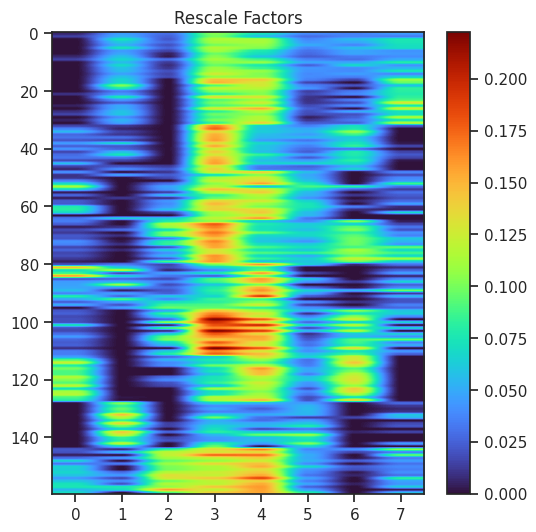

In [ ]:
#%%

## Inspect the context, and evalualte the gate layer
contexts = learner.contexts
network = trainer.learner.model.vectorfield.neuralnet

# @eqx.filter_vmap
# def gate_fn(ctx):
#     ctx_fam, ctx_env = jnp.split(ctx, 2, axis=0)

#     in_dat = jnp.concatenate((jnp.array([0.]), jnp.array([0.,0.]), ctx_fam), axis=0)
#     # H = network.gate_weight@ctx
#     H = network.gate["function"](network.gate, ctx)

#     topk_vals, topk_idx = jax.lax.top_k(H, top_k)
#     infs = jnp.full_like(H, -jnp.inf)
#     infs = infs.at[topk_idx].set(topk_vals)
#     G = jax.nn.softmax(infs)

#     return G

# gate_vals = gate_fn(contexts.params)

# fig, ax = plt.subplots(1, 1, figsize=(6, 6))
# ## sort and plot histogram of gate values
# # gate_vals = jnp.sort(gate_vals.flatten())
# ax.hist(gate_vals.flatten(), bins=50);

# ax.set_title(f"Gate Histogram with Top-K = {top_k}")
# print(gate_vals)
# # print(gate_vals.sum(axis=0))
# # print(network.gate_weight)

# plt.draw()
# plt.savefig(run_folder+"gate_histogram.png")



#### Plot the rescaling factors
@eqx.filter_vmap
def rescale_fn(ctx):
    scales = []
    for i in range(nb_experts):
        factor = jax.nn.relu(network.experts[i].rescaler(ctx).squeeze())
        scales.append(factor)
    return jnp.array(scales)

rescale_vals = rescale_fn(contexts.params)  ## (nb_envs, nb_experts)

## Visualise as an imshow
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
img = ax.imshow(rescale_vals, aspect='auto', cmap='turbo')
plt.colorbar(img)
ax.set_title("Rescale Factors")
plt.draw()
plt.savefig(run_folder+"rescale_factors.png")

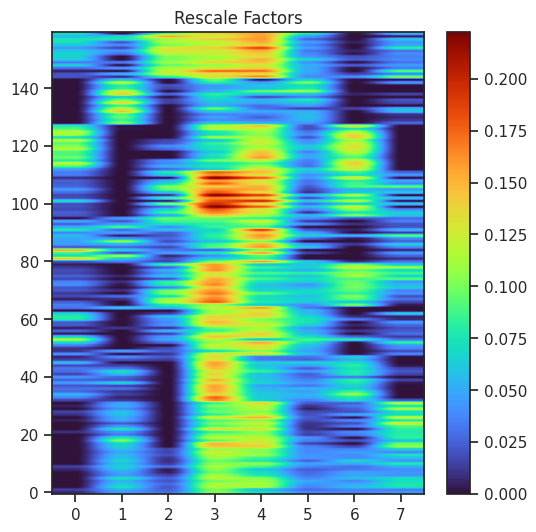

In [ ]:
#%%

## Inspect the context, and evalualte the gate layer
contexts = learner.contexts
network = trainer.learner.model.vectorfield.neuralnet

# @eqx.filter_vmap
# def gate_fn(ctx):
#     ctx_fam, ctx_env = jnp.split(ctx, 2, axis=0)

#     in_dat = jnp.concatenate((jnp.array([0.]), jnp.array([0.,0.]), ctx_fam), axis=0)
#     # H = network.gate_weight@ctx
#     H = network.gate["function"](network.gate, ctx)

#     topk_vals, topk_idx = jax.lax.top_k(H, top_k)
#     infs = jnp.full_like(H, -jnp.inf)
#     infs = infs.at[topk_idx].set(topk_vals)
#     G = jax.nn.softmax(infs)

#     return G

# gate_vals = gate_fn(contexts.params)

# fig, ax = plt.subplots(1, 1, figsize=(6, 6))
# ## sort and plot histogram of gate values
# # gate_vals = jnp.sort(gate_vals.flatten())
# ax.hist(gate_vals.flatten(), bins=50);

# ax.set_title(f"Gate Histogram with Top-K = {top_k}")
# print(gate_vals)
# # print(gate_vals.sum(axis=0))
# # print(network.gate_weight)

# plt.draw()
# plt.savefig(run_folder+"gate_histogram.png")



#### Plot the rescaling factors
@eqx.filter_vmap
def rescale_fn(ctx):
    scales = []
    for i in range(nb_experts):
        factor = jax.nn.relu(network.experts[i].rescaler(ctx).squeeze())
        scales.append(factor)
    return jnp.array(scales)

rescale_vals = rescale_fn(contexts.params)  ## (nb_envs, nb_experts)

## Visualise as an imshow
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
img = ax.imshow(rescale_vals, aspect='auto', cmap='turbo', origin='lower', interpolation=None)
plt.colorbar(img)
ax.set_title("Rescale Factors")
plt.draw()
plt.savefig(run_folder+"rescale_factors.png")

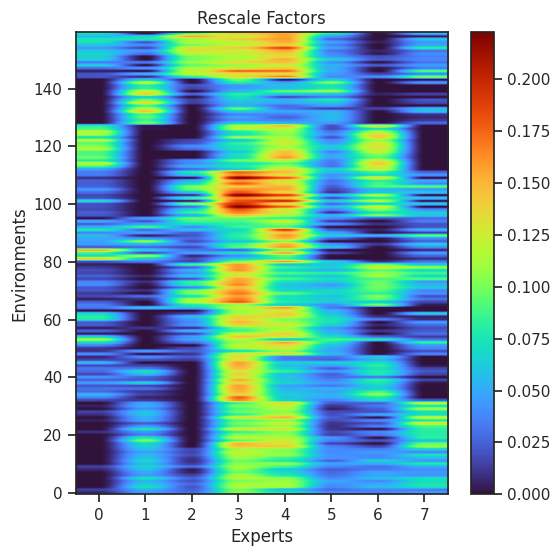

In [ ]:
#%%

## Inspect the context, and evalualte the gate layer
contexts = learner.contexts
network = trainer.learner.model.vectorfield.neuralnet

# @eqx.filter_vmap
# def gate_fn(ctx):
#     ctx_fam, ctx_env = jnp.split(ctx, 2, axis=0)

#     in_dat = jnp.concatenate((jnp.array([0.]), jnp.array([0.,0.]), ctx_fam), axis=0)
#     # H = network.gate_weight@ctx
#     H = network.gate["function"](network.gate, ctx)

#     topk_vals, topk_idx = jax.lax.top_k(H, top_k)
#     infs = jnp.full_like(H, -jnp.inf)
#     infs = infs.at[topk_idx].set(topk_vals)
#     G = jax.nn.softmax(infs)

#     return G

# gate_vals = gate_fn(contexts.params)

# fig, ax = plt.subplots(1, 1, figsize=(6, 6))
# ## sort and plot histogram of gate values
# # gate_vals = jnp.sort(gate_vals.flatten())
# ax.hist(gate_vals.flatten(), bins=50);

# ax.set_title(f"Gate Histogram with Top-K = {top_k}")
# print(gate_vals)
# # print(gate_vals.sum(axis=0))
# # print(network.gate_weight)

# plt.draw()
# plt.savefig(run_folder+"gate_histogram.png")



#### Plot the rescaling factors
@eqx.filter_vmap
def rescale_fn(ctx):
    scales = []
    for i in range(nb_experts):
        factor = jax.nn.relu(network.experts[i].rescaler(ctx).squeeze())
        scales.append(factor)
    return jnp.array(scales)

rescale_vals = rescale_fn(contexts.params)  ## (nb_envs, nb_experts)

## Visualise as an imshow
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
img = ax.imshow(rescale_vals, aspect='auto', cmap='turbo', origin='lower', interpolation=None)
plt.colorbar(img)
ax.set_xlabel("Experts")
ax.set_ylabel("Environments")
ax.set_title("Rescale Factors")
plt.draw()
plt.savefig(run_folder+"rescale_factors.png")

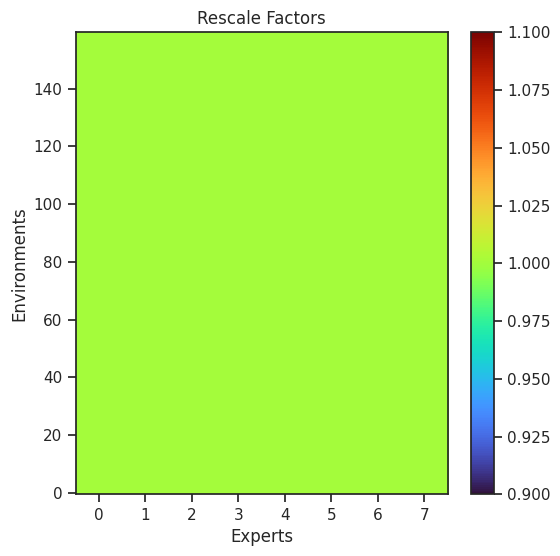

In [ ]:
#%%

## Inspect the context, and evalualte the gate layer
contexts = learner.contexts
network = trainer.learner.model.vectorfield.neuralnet

# @eqx.filter_vmap
# def gate_fn(ctx):
#     ctx_fam, ctx_env = jnp.split(ctx, 2, axis=0)

#     in_dat = jnp.concatenate((jnp.array([0.]), jnp.array([0.,0.]), ctx_fam), axis=0)
#     # H = network.gate_weight@ctx
#     H = network.gate["function"](network.gate, ctx)

#     topk_vals, topk_idx = jax.lax.top_k(H, top_k)
#     infs = jnp.full_like(H, -jnp.inf)
#     infs = infs.at[topk_idx].set(topk_vals)
#     G = jax.nn.softmax(infs)

#     return G

# gate_vals = gate_fn(contexts.params)

# fig, ax = plt.subplots(1, 1, figsize=(6, 6))
# ## sort and plot histogram of gate values
# # gate_vals = jnp.sort(gate_vals.flatten())
# ax.hist(gate_vals.flatten(), bins=50);

# ax.set_title(f"Gate Histogram with Top-K = {top_k}")
# print(gate_vals)
# # print(gate_vals.sum(axis=0))
# # print(network.gate_weight)

# plt.draw()
# plt.savefig(run_folder+"gate_histogram.png")



#### Plot the rescaling factors
@eqx.filter_vmap
def rescale_fn(ctx):
    scales = []
    for i in range(nb_experts):
        factor = jax.nn.relu(network.experts[i].rescaler(ctx).squeeze())
        factor = jnp.clip(factor, 1, 1e2)
        scales.append(factor)
    return jnp.array(scales)

rescale_vals = rescale_fn(contexts.params)  ## (nb_envs, nb_experts)

## Visualise as an imshow
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
img = ax.imshow(rescale_vals, aspect='auto', cmap='turbo', origin='lower', interpolation=None)
plt.colorbar(img)
ax.set_xlabel("Experts")
ax.set_ylabel("Environments")
ax.set_title("Rescale Factors")
plt.draw()
plt.savefig(run_folder+"rescale_factors.png")

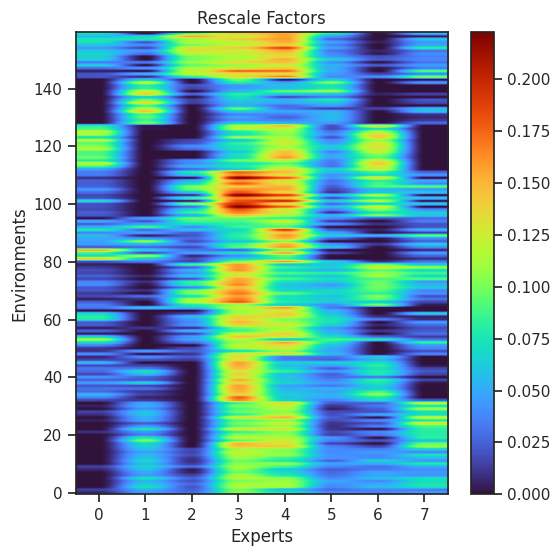

In [ ]:
#%%

## Inspect the context, and evalualte the gate layer
contexts = learner.contexts
network = trainer.learner.model.vectorfield.neuralnet

# @eqx.filter_vmap
# def gate_fn(ctx):
#     ctx_fam, ctx_env = jnp.split(ctx, 2, axis=0)

#     in_dat = jnp.concatenate((jnp.array([0.]), jnp.array([0.,0.]), ctx_fam), axis=0)
#     # H = network.gate_weight@ctx
#     H = network.gate["function"](network.gate, ctx)

#     topk_vals, topk_idx = jax.lax.top_k(H, top_k)
#     infs = jnp.full_like(H, -jnp.inf)
#     infs = infs.at[topk_idx].set(topk_vals)
#     G = jax.nn.softmax(infs)

#     return G

# gate_vals = gate_fn(contexts.params)

# fig, ax = plt.subplots(1, 1, figsize=(6, 6))
# ## sort and plot histogram of gate values
# # gate_vals = jnp.sort(gate_vals.flatten())
# ax.hist(gate_vals.flatten(), bins=50);

# ax.set_title(f"Gate Histogram with Top-K = {top_k}")
# print(gate_vals)
# # print(gate_vals.sum(axis=0))
# # print(network.gate_weight)

# plt.draw()
# plt.savefig(run_folder+"gate_histogram.png")



#### Plot the rescaling factors
@eqx.filter_vmap
def rescale_fn(ctx):
    scales = []
    for i in range(nb_experts):
        factor = jax.nn.relu(network.experts[i].rescaler(ctx).squeeze())
        # factor = jnp.clip(factor, 1, 1e2)
        scales.append(factor)
    return jnp.array(scales)

rescale_vals = rescale_fn(contexts.params)  ## (nb_envs, nb_experts)

## Visualise as an imshow
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
img = ax.imshow(rescale_vals, aspect='auto', cmap='turbo', origin='lower', interpolation=None)
plt.colorbar(img)
ax.set_xlabel("Experts")
ax.set_ylabel("Environments")
ax.set_title("Rescale Factors")
plt.draw()
plt.savefig(run_folder+"rescale_factors.png")

[[0.         0.         0.16769493 0.1900186  0.17703654 0.14725433 0.15608543 0.16191012]
 [0.         0.         0.16968127 0.18726648 0.1766799  0.14688244 0.15678649 0.16270341]
 [0.         0.         0.16217352 0.1942552  0.179564   0.1467826  0.15742953 0.15979506]
 [0.         0.         0.1621419  0.1937653  0.17973855 0.14682253 0.15679568 0.16073611]
 [0.         0.         0.16460283 0.1847148  0.17527205 0.15015064 0.15853244 0.16672724]
 [0.         0.         0.16305657 0.19049567 0.17982826 0.14733696 0.15751214 0.16177042]
 [0.         0.         0.16802259 0.18255363 0.18387894 0.1478913  0.15520948 0.16244406]
 [0.         0.         0.16826911 0.18426965 0.17788933 0.1497907  0.15494584 0.16483536]
 [0.         0.         0.17023596 0.17967111 0.18090047 0.14891745 0.15560648 0.16466849]
 [0.         0.         0.16179818 0.1855203  0.17757756 0.1529158  0.15625207 0.16593611]
 [0.         0.         0.16466694 0.1837207  0.18633963 0.14918564 0.15361376 0.16247332]

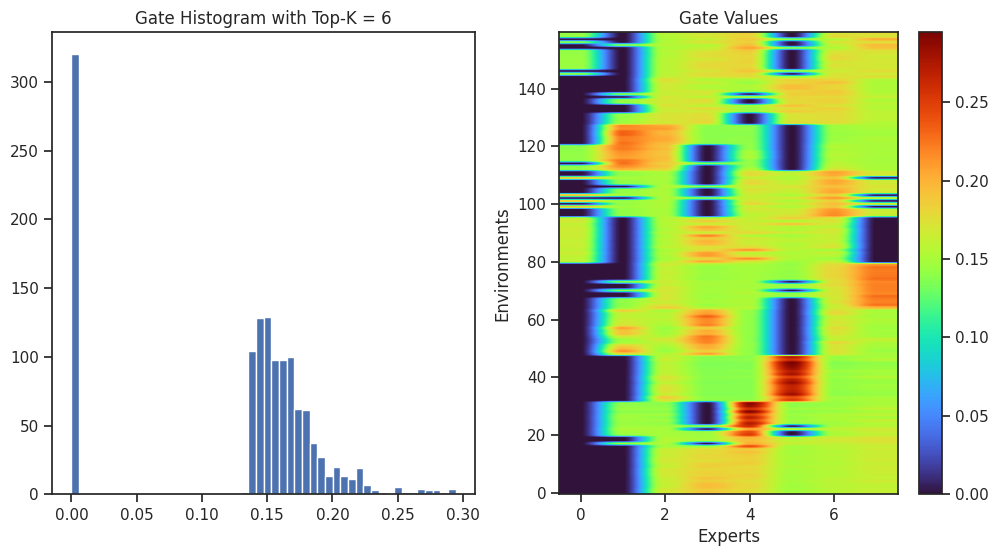

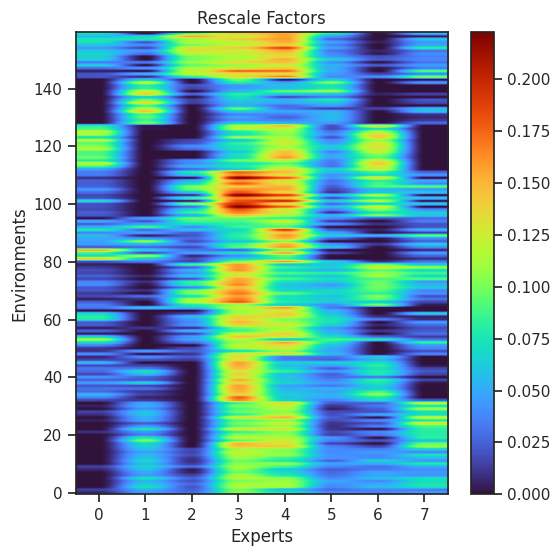

In [ ]:
#%%

## Inspect the context, and evalualte the gate layer
contexts = learner.contexts
network = trainer.learner.model.vectorfield.neuralnet

@eqx.filter_vmap
def gate_fn(ctx):
    ctx_fam, ctx_env = jnp.split(ctx, 2, axis=0)

    in_dat = jnp.concatenate((jnp.array([0.]), jnp.array([0.,0.]), ctx_fam), axis=0)
    # H = network.gate_weight@ctx
    H = network.gate["function"](network.gate, ctx)

    topk_vals, topk_idx = jax.lax.top_k(H, top_k)
    infs = jnp.full_like(H, -jnp.inf)
    infs = infs.at[topk_idx].set(topk_vals)
    G = jax.nn.softmax(infs)

    return G

gate_vals = gate_fn(contexts.params)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(6*2, 6))
## sort and plot histogram of gate values
# gate_vals = jnp.sort(gate_vals.flatten())
ax.hist(gate_vals.flatten(), bins=50);

ax.set_title(f"Gate Histogram with Top-K = {top_k}")
print(gate_vals)

## inshow on ax2
img = ax2.imshow(gate_vals, aspect='auto', cmap='turbo', origin='lower', interpolation=None)
plt.colorbar(img)
ax2.set_xlabel("Experts")
ax2.set_ylabel("Environments")
ax2.set_title("Gate Values")

plt.draw()
plt.savefig(run_folder+"gate_histogram_big.png")



#### Plot the rescaling factors
@eqx.filter_vmap
def rescale_fn(ctx):
    scales = []
    for i in range(nb_experts):
        factor = jax.nn.relu(network.experts[i].rescaler(ctx).squeeze())
        # factor = jnp.clip(factor, 1, 1e2)
        scales.append(factor)
    return jnp.array(scales)

rescale_vals = rescale_fn(contexts.params)  ## (nb_envs, nb_experts)

## Visualise as an imshow
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
img = ax.imshow(rescale_vals, aspect='auto', cmap='turbo', origin='lower', interpolation=None)
plt.colorbar(img)
ax.set_xlabel("Experts")
ax.set_ylabel("Environments")
ax.set_title("Rescale Factors")
plt.draw()
plt.savefig(run_folder+"rescale_factors.png")

[[0.         0.         0.16769493 0.1900186  0.17703654 0.14725433 0.15608543 0.16191012]
 [0.         0.         0.16968127 0.18726648 0.1766799  0.14688244 0.15678649 0.16270341]
 [0.         0.         0.16217352 0.1942552  0.179564   0.1467826  0.15742953 0.15979506]
 [0.         0.         0.1621419  0.1937653  0.17973855 0.14682253 0.15679568 0.16073611]
 [0.         0.         0.16460283 0.1847148  0.17527205 0.15015064 0.15853244 0.16672724]
 [0.         0.         0.16305657 0.19049567 0.17982826 0.14733696 0.15751214 0.16177042]
 [0.         0.         0.16802259 0.18255363 0.18387894 0.1478913  0.15520948 0.16244406]
 [0.         0.         0.16826911 0.18426965 0.17788933 0.1497907  0.15494584 0.16483536]
 [0.         0.         0.17023596 0.17967111 0.18090047 0.14891745 0.15560648 0.16466849]
 [0.         0.         0.16179818 0.1855203  0.17757756 0.1529158  0.15625207 0.16593611]
 [0.         0.         0.16466694 0.1837207  0.18633963 0.14918564 0.15361376 0.16247332]

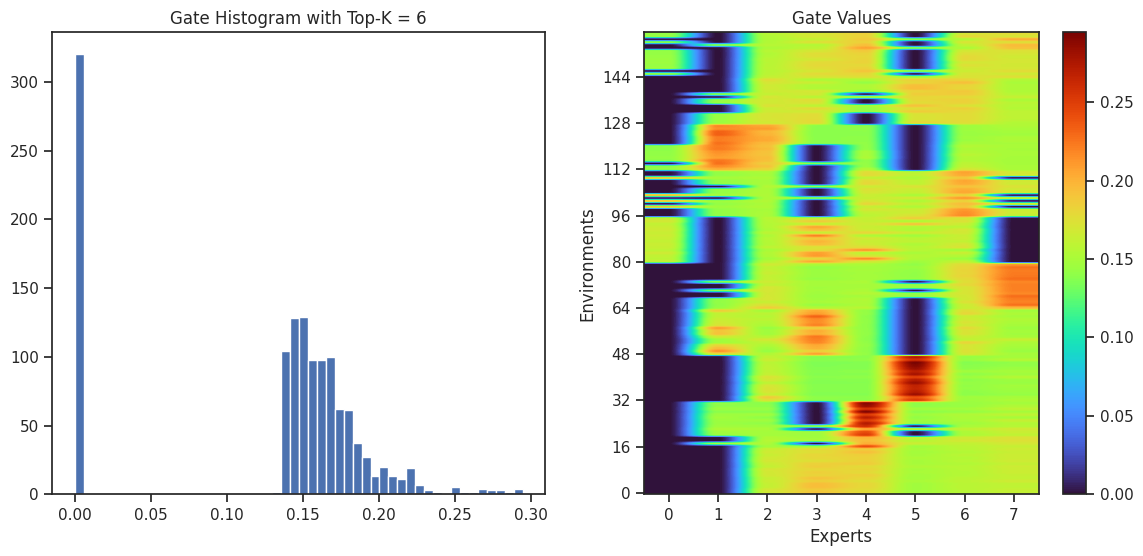

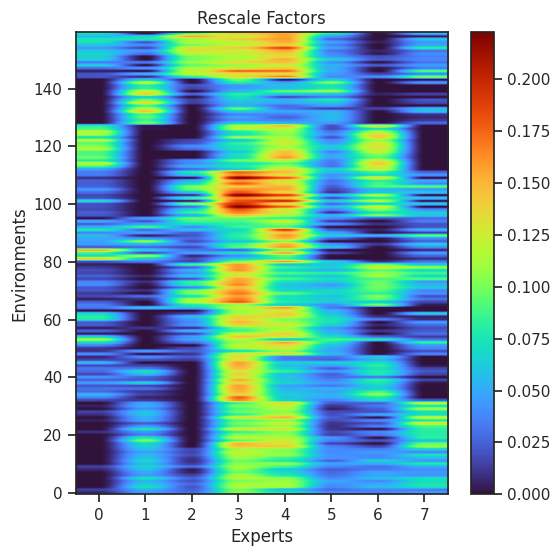

In [ ]:
#%%

## Inspect the context, and evalualte the gate layer
contexts = learner.contexts
network = trainer.learner.model.vectorfield.neuralnet

@eqx.filter_vmap
def gate_fn(ctx):
    ctx_fam, ctx_env = jnp.split(ctx, 2, axis=0)

    in_dat = jnp.concatenate((jnp.array([0.]), jnp.array([0.,0.]), ctx_fam), axis=0)
    # H = network.gate_weight@ctx
    H = network.gate["function"](network.gate, ctx)

    topk_vals, topk_idx = jax.lax.top_k(H, top_k)
    infs = jnp.full_like(H, -jnp.inf)
    infs = infs.at[topk_idx].set(topk_vals)
    G = jax.nn.softmax(infs)

    return G

gate_vals = gate_fn(contexts.params)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(7*2, 6))
## sort and plot histogram of gate values
# gate_vals = jnp.sort(gate_vals.flatten())
ax.hist(gate_vals.flatten(), bins=50);

ax.set_title(f"Gate Histogram with Top-K = {top_k}")
print(gate_vals)

## inshow on ax2
img = ax2.imshow(gate_vals, aspect='auto', cmap='turbo', origin='lower', interpolation=None)
plt.colorbar(img)
ax2.set_xlabel("Experts")
ax2.set_ylabel("Environments")

## Set yticks in steps of 16
ax2.set_yticks(np.arange(0, 16*ode_count, 16))
ax2.set_yticklabels(np.arange(0, 16*ode_count, 16))

ax2.set_title("Gate Values")

plt.draw()
plt.savefig(run_folder+"gate_histogram_big.png")



#### Plot the rescaling factors
@eqx.filter_vmap
def rescale_fn(ctx):
    scales = []
    for i in range(nb_experts):
        factor = jax.nn.relu(network.experts[i].rescaler(ctx).squeeze())
        # factor = jnp.clip(factor, 1, 1e2)
        scales.append(factor)
    return jnp.array(scales)

rescale_vals = rescale_fn(contexts.params)  ## (nb_envs, nb_experts)

## Visualise as an imshow
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
img = ax.imshow(rescale_vals, aspect='auto', cmap='turbo', origin='lower', interpolation=None)
plt.colorbar(img)
ax.set_xlabel("Experts")
ax.set_ylabel("Environments")
ax.set_title("Rescale Factors")
plt.draw()
plt.savefig(run_folder+"rescale_factors.png")

Shapes of data and t_eval: (160, 4, 25, 2) (160, 25)


IndexError: list index out of range

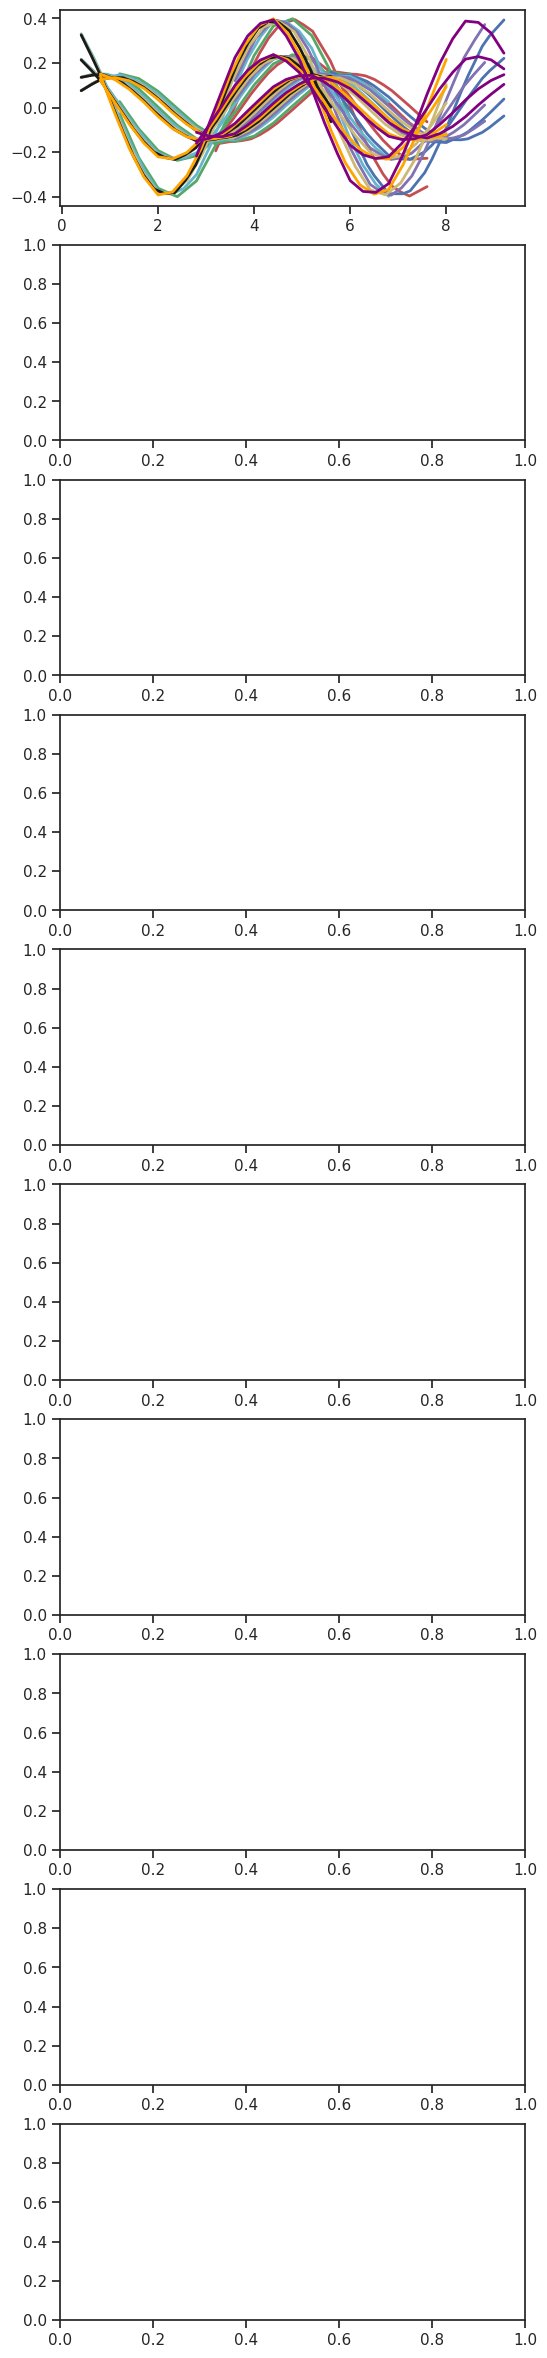

In [ ]:
#%%

# ## Plot all trajectories in the first 9 environments
# plt_data = train_dataloader.dataset.dataset
# plt_t = train_dataloader.dataset.t_eval

## Alternative way to gather the data
(ins, ts), outs = next(iter(train_dataloader))
plt_data = outs
plt_t = ts

print("Shapes of data and t_eval:", plt_data.shape, plt_t.shape)

E_plot = 10
E_ = 16

fig, ax = plt.subplots(E_plot, 1, figsize=(6, E_plot*3))
if E_plot==1:
    ax = [ax]
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple']
for e in range(E_plot):
    e_plot_data = plt_data[e*E_:(e+1)*E_, :, :, 0]
    e_t_eval = plt_t[e*E_:(e+1)*E_]
    for e_ in range(E_):
        # ax[e].plot(e_plot_data[e_].T, '-', color=colors[e_])
        ax[e].plot(e_t_eval[e_], e_plot_data[e_].T, '-', color=colors[e_])
        # if e==1:
        #     print("t_eval is:", e_t_eval[e_])
    ax[e].set_title(f"Environment {23+e}")
    ax[e].set_xlabel("time")
    ax[e].set_ylabel("y_0")

plt.tight_layout()
plt.show()

Shapes of data and t_eval: (160, 4, 25, 2) (160, 25)


IndexError: list index out of range

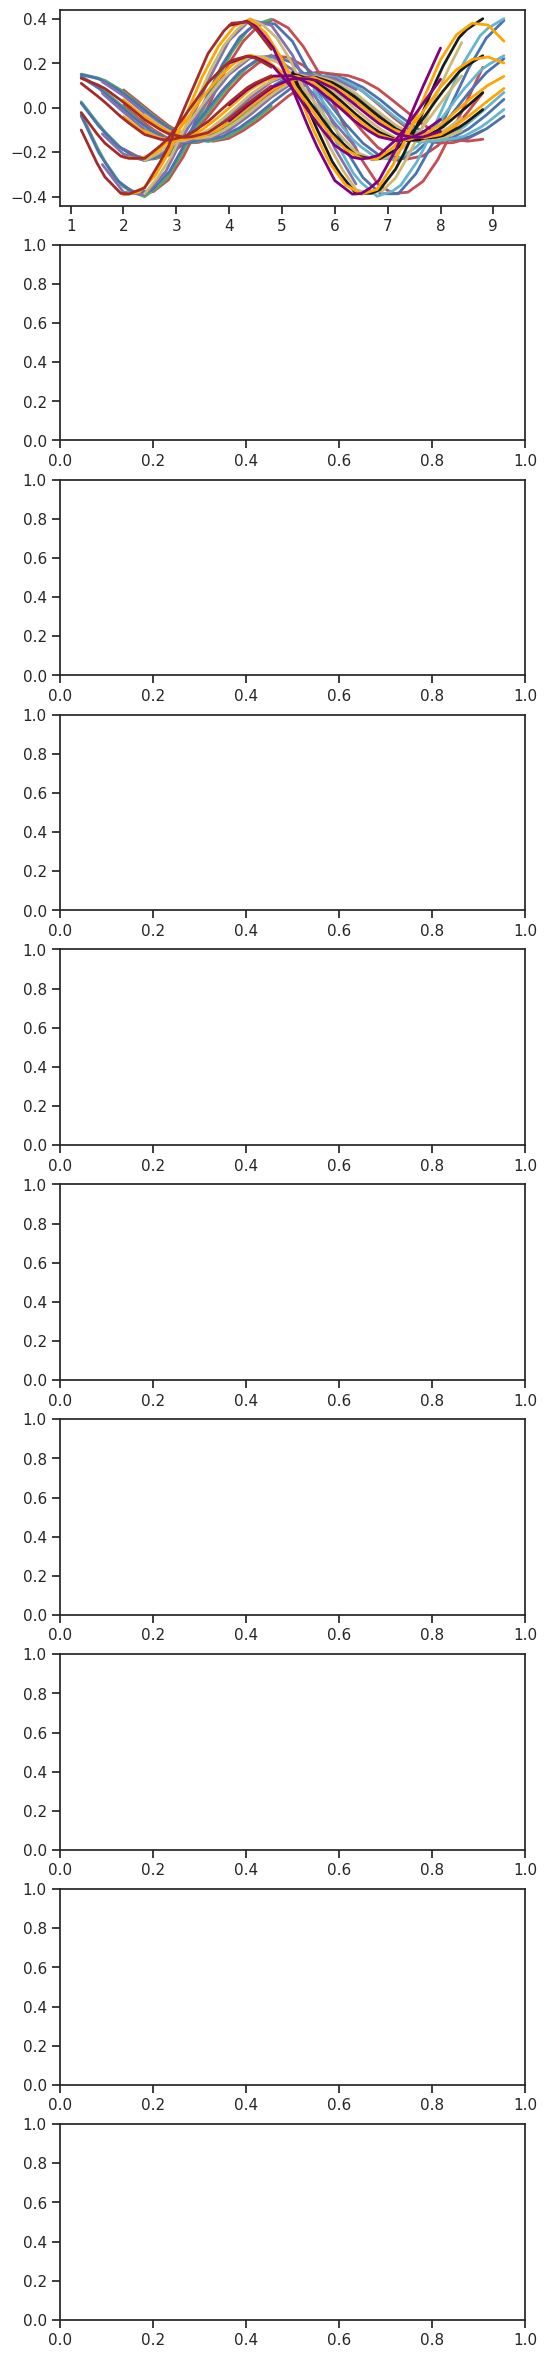

In [ ]:
#%%

# ## Plot all trajectories in the first 9 environments
# plt_data = train_dataloader.dataset.dataset
# plt_t = train_dataloader.dataset.t_eval

## Alternative way to gather the data
(ins, ts), outs = next(iter(train_dataloader))
plt_data = outs
plt_t = ts

print("Shapes of data and t_eval:", plt_data.shape, plt_t.shape)

E_plot = 10
E_ = 16

fig, ax = plt.subplots(E_plot, 1, figsize=(6, E_plot*3))
if E_plot==1:
    ax = [ax]
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']
for e in range(E_plot):
    e_plot_data = plt_data[e*E_:(e+1)*E_, :, :, 0]
    e_t_eval = plt_t[e*E_:(e+1)*E_]
    for e_ in range(E_):
        # ax[e].plot(e_plot_data[e_].T, '-', color=colors[e_])
        ax[e].plot(e_t_eval[e_], e_plot_data[e_].T, '-', color=colors[e_])
        # if e==1:
        #     print("t_eval is:", e_t_eval[e_])
    ax[e].set_title(f"Environment {23+e}")
    ax[e].set_xlabel("time")
    ax[e].set_ylabel("y_0")

plt.tight_layout()
plt.show()

Shapes of data and t_eval: (160, 4, 25, 2) (160, 25)


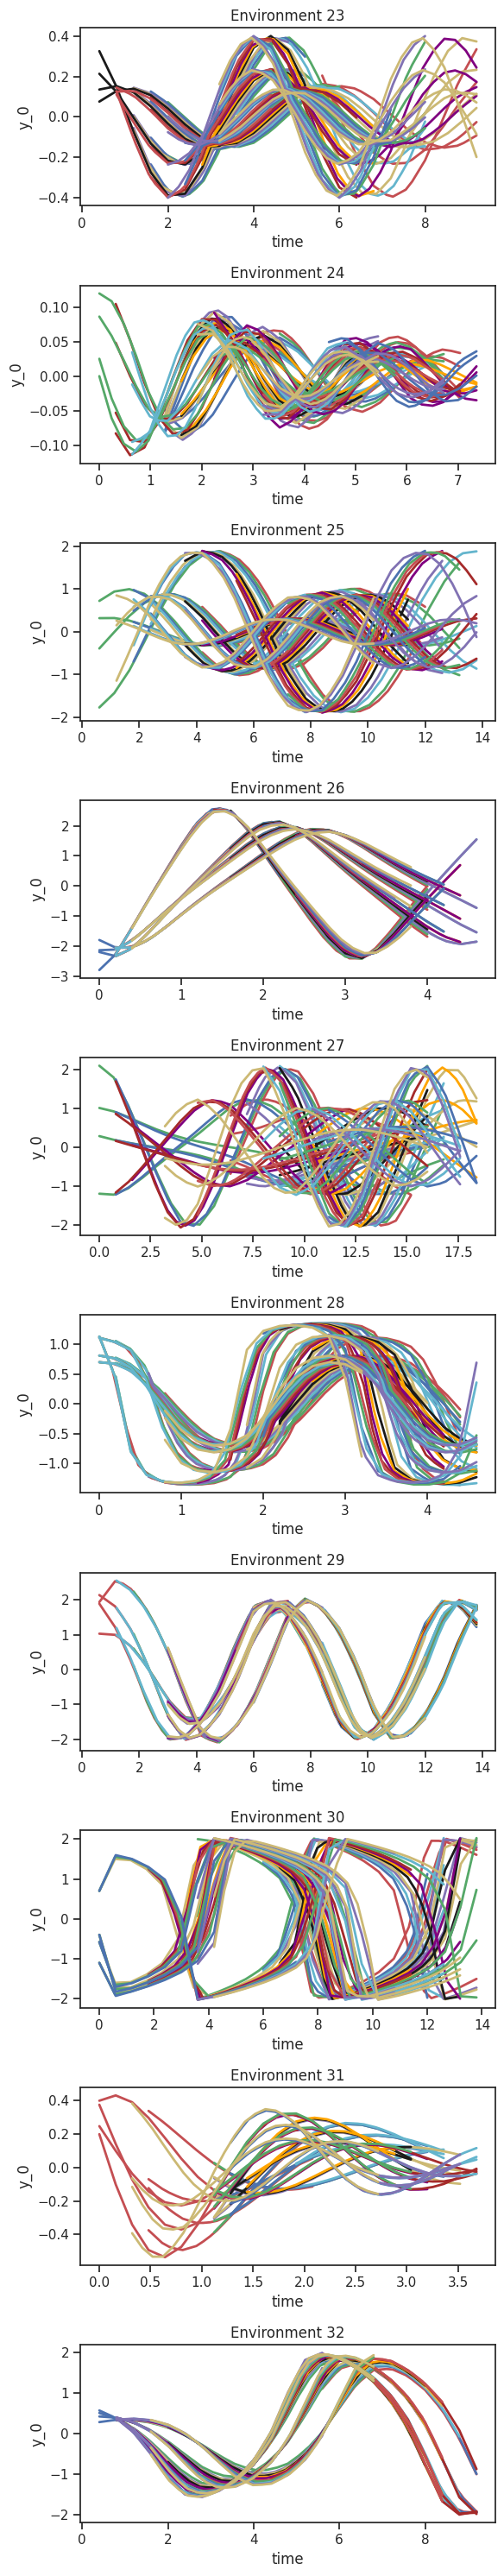

In [ ]:
#%%

# ## Plot all trajectories in the first 9 environments
# plt_data = train_dataloader.dataset.dataset
# plt_t = train_dataloader.dataset.t_eval

## Alternative way to gather the data
(ins, ts), outs = next(iter(train_dataloader))
plt_data = outs
plt_t = ts

print("Shapes of data and t_eval:", plt_data.shape, plt_t.shape)

E_plot = 10
E_ = 16

fig, ax = plt.subplots(E_plot, 1, figsize=(6, E_plot*3))
if E_plot==1:
    ax = [ax]
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'r', 'g', 'b', 'c', 'm', 'y']
for e in range(E_plot):
    e_plot_data = plt_data[e*E_:(e+1)*E_, :, :, 0]
    e_t_eval = plt_t[e*E_:(e+1)*E_]
    for e_ in range(E_):
        # ax[e].plot(e_plot_data[e_].T, '-', color=colors[e_])
        ax[e].plot(e_t_eval[e_], e_plot_data[e_].T, '-', color=colors[e_])
        # if e==1:
        #     print("t_eval is:", e_t_eval[e_])
    ax[e].set_title(f"Environment {23+e}")
    ax[e].set_xlabel("time")
    ax[e].set_ylabel("y_0")

plt.tight_layout()
plt.show()

Shapes of data and t_eval: (160, 4, 25, 2) (160, 25)


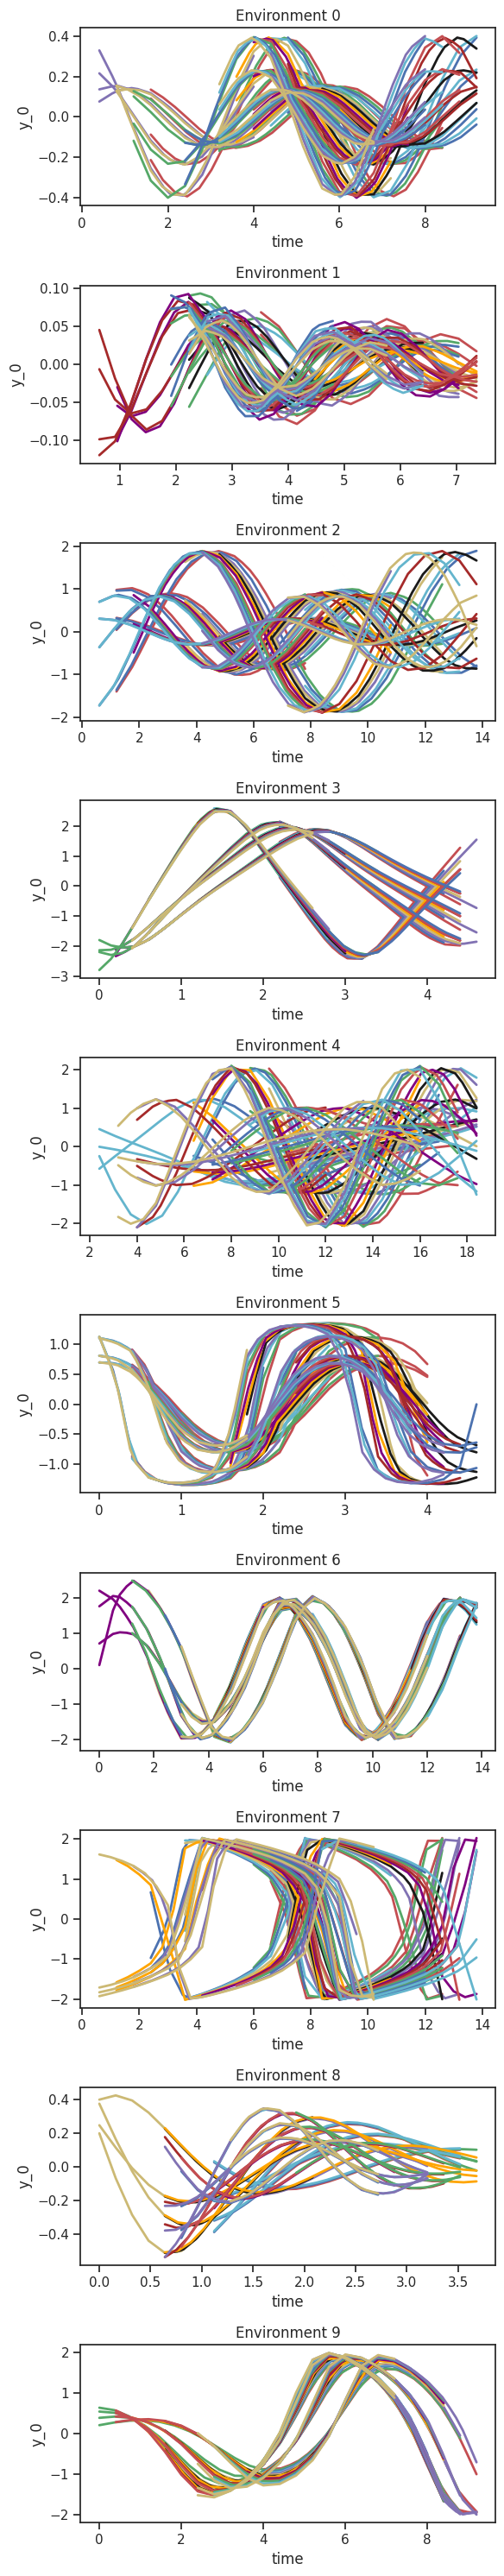

In [ ]:
#%%

# ## Plot all trajectories in the first 9 environments
# plt_data = train_dataloader.dataset.dataset
# plt_t = train_dataloader.dataset.t_eval

## Alternative way to gather the data
(ins, ts), outs = next(iter(train_dataloader))
plt_data = outs
plt_t = ts

print("Shapes of data and t_eval:", plt_data.shape, plt_t.shape)

E_plot = 10
E_ = 16

fig, ax = plt.subplots(E_plot, 1, figsize=(6, E_plot*3))
if E_plot==1:
    ax = [ax]
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'r', 'g', 'b', 'c', 'm', 'y']
for e in range(E_plot):
    e_plot_data = plt_data[e*E_:(e+1)*E_, :, :, 0]
    e_t_eval = plt_t[e*E_:(e+1)*E_]
    for e_ in range(E_):
        # ax[e].plot(e_plot_data[e_].T, '-', color=colors[e_])
        ax[e].plot(e_t_eval[e_], e_plot_data[e_].T, '-', color=colors[e_])
        # if e==1:
        #     print("t_eval is:", e_t_eval[e_])
    # ax[e].set_title(f"Environment {23+e}")
    ax[e].set_title(f"Environment {e}")
    ax[e].set_xlabel("time")
    ax[e].set_ylabel("y_0")

plt.tight_layout()
plt.draw()
plt.savefig(run_folder+"train_trajectories.png")

[[0.         0.         0.16769493 0.1900186  0.17703654 0.14725433 0.15608543 0.16191012]
 [0.         0.         0.16968127 0.18726648 0.1766799  0.14688244 0.15678649 0.16270341]
 [0.         0.         0.16217352 0.1942552  0.179564   0.1467826  0.15742953 0.15979506]
 [0.         0.         0.1621419  0.1937653  0.17973855 0.14682253 0.15679568 0.16073611]
 [0.         0.         0.16460283 0.1847148  0.17527205 0.15015064 0.15853244 0.16672724]
 [0.         0.         0.16305657 0.19049567 0.17982826 0.14733696 0.15751214 0.16177042]
 [0.         0.         0.16802259 0.18255363 0.18387894 0.1478913  0.15520948 0.16244406]
 [0.         0.         0.16826911 0.18426965 0.17788933 0.1497907  0.15494584 0.16483536]
 [0.         0.         0.17023596 0.17967111 0.18090047 0.14891745 0.15560648 0.16466849]
 [0.         0.         0.16179818 0.1855203  0.17757756 0.1529158  0.15625207 0.16593611]
 [0.         0.         0.16466694 0.1837207  0.18633963 0.14918564 0.15361376 0.16247332]

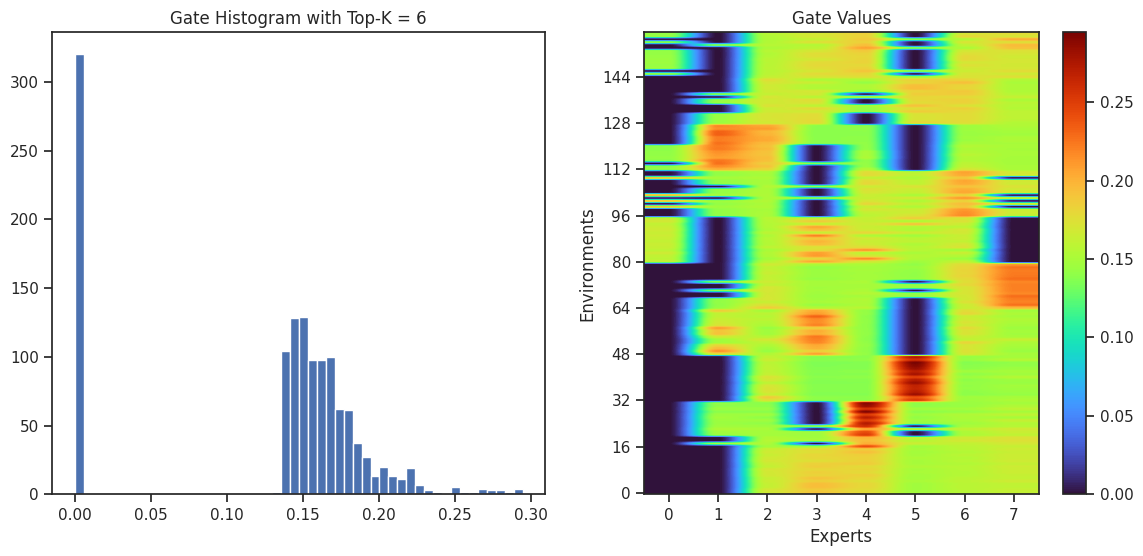

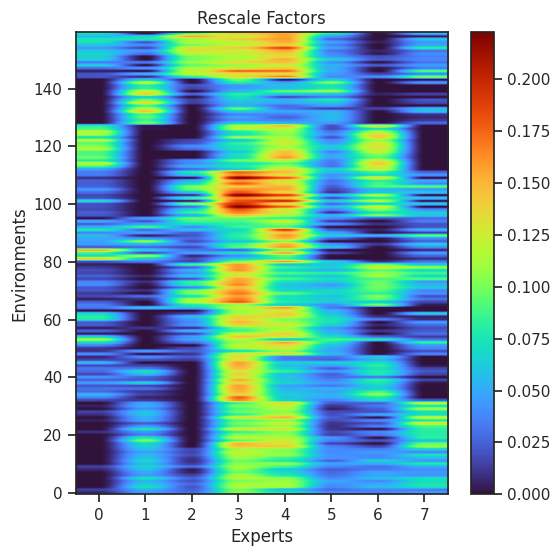

In [ ]:
#%%

## Inspect the context, and evalualte the gate layer
contexts = learner.contexts
network = trainer.learner.model.vectorfield.neuralnet

@eqx.filter_vmap
def gate_fn(ctx):
    ctx_fam, ctx_env = jnp.split(ctx, 2, axis=0)

    in_dat = jnp.concatenate((jnp.array([0.]), jnp.array([0.,0.]), ctx_fam), axis=0)
    # H = network.gate_weight@ctx
    H = network.gate["function"](network.gate, ctx)

    topk_vals, topk_idx = jax.lax.top_k(H, top_k)
    infs = jnp.full_like(H, -jnp.inf)
    infs = infs.at[topk_idx].set(topk_vals)
    G = jax.nn.softmax(infs)

    return G

gate_vals = gate_fn(contexts.params)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(7*2, 6))
## sort and plot histogram of gate values
# gate_vals = jnp.sort(gate_vals.flatten())
ax.hist(gate_vals.flatten(), bins=50);

ax.set_title(f"Gate Histogram with Top-K = {top_k}")
print(gate_vals)

## inshow on ax2
img = ax2.imshow(gate_vals, aspect='auto', cmap='turbo', origin='lower', interpolation=None)
plt.colorbar(img)
ax2.set_xlabel("Experts")
ax2.set_ylabel("Environments")

## Set yticks in steps of 16
ax2.set_yticks(np.arange(0, 16*ode_count, 16))
ax2.set_yticklabels(np.arange(0, 16*ode_count, 16))

ax2.set_title("Gate Values")

plt.draw()
plt.savefig(run_folder+"gate_histogram_big.png")



#### Plot the rescaling factors
@eqx.filter_vmap
def rescale_fn(ctx):
    scales = []
    for i in range(nb_experts):
        factor = jax.nn.relu(network.experts[i].rescaler(ctx).squeeze())
        # factor = jnp.clip(factor, 1, 1e2)
        scales.append(factor)
    return jnp.array(scales)

rescale_vals = rescale_fn(contexts.params)  ## (nb_envs, nb_experts)

## Visualise as an imshow
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
img = ax.imshow(rescale_vals, aspect='auto', cmap='turbo', origin='lower', interpolation=None)
plt.colorbar(img)
ax.set_xlabel("Experts")
ax.set_ylabel("Environments")
ax.set_title("Rescale Factors")
plt.draw()
plt.savefig(run_folder+"rescale_factors.png")

Shapes of data and t_eval: (160, 4, 25, 2) (160, 25)


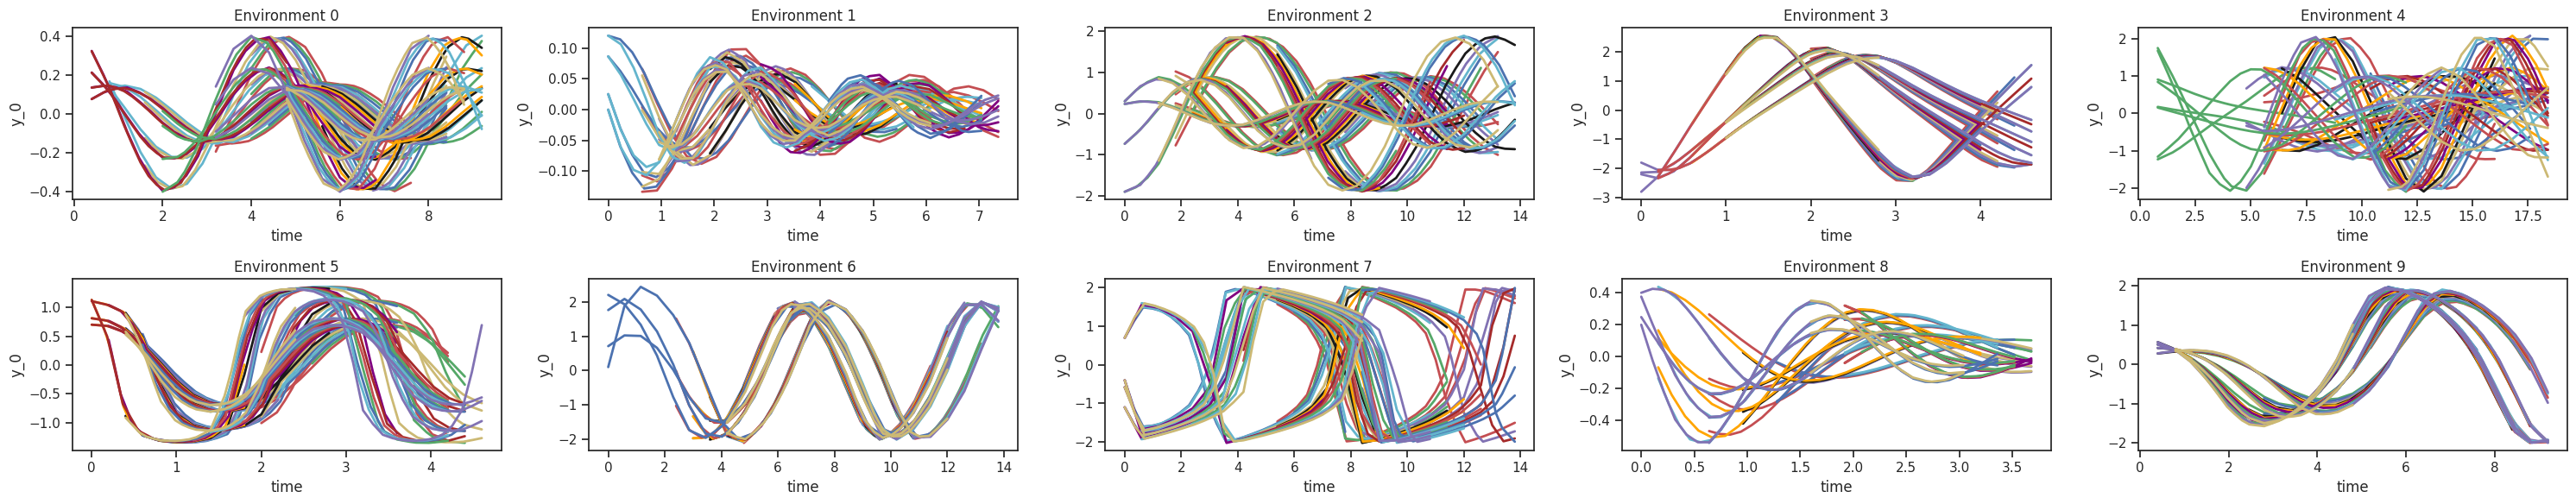

In [ ]:
#%%

# ## Plot all trajectories in the first 9 environments
# plt_data = train_dataloader.dataset.dataset
# plt_t = train_dataloader.dataset.t_eval

## Alternative way to gather the data
(ins, ts), outs = next(iter(train_dataloader))
plt_data = outs
plt_t = ts

print("Shapes of data and t_eval:", plt_data.shape, plt_t.shape)

E_plot = 10
E_ = 16

# fig, ax = plt.subplots(E_plot, 1, figsize=(6, E_plot*3))
fig, ax = plt.subplots(2, E_plot//2, figsize=(6*E_plot//2, 3*2))
ax = ax.flatten()
if E_plot==1:
    ax = [ax]
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'r', 'g', 'b', 'c', 'm', 'y']
for e in range(E_plot):
    e_plot_data = plt_data[e*E_:(e+1)*E_, :, :, 0]
    e_t_eval = plt_t[e*E_:(e+1)*E_]
    for e_ in range(E_):
        # ax[e].plot(e_plot_data[e_].T, '-', color=colors[e_])
        ax[e].plot(e_t_eval[e_], e_plot_data[e_].T, '-', color=colors[e_])
        # if e==1:
        #     print("t_eval is:", e_t_eval[e_])
    # ax[e].set_title(f"Environment {23+e}")
    ax[e].set_title(f"Environment {e}")
    ax[e].set_xlabel("time")
    ax[e].set_ylabel("y_0")

plt.tight_layout()
plt.draw()
plt.savefig(run_folder+"train_trajectories.png")

In [ ]:
#%%

## Adapt the model to the new dataset
if meta_test:
    adapt_id = 4*4+1     ## The single environment to adapt to (the difficult rectangular one)

    adapt_dataset = ODEBenchDataset(data_dir=data_folder+"adapt_train.npz", 
                                    adaptation=True,
                                    # norm_consts=data_folder+"adapt_train_bounds.npy",
                                    num_shots=num_shots[0], 
                                    skip_steps=skip_steps,
                                    traj_prop_min=train_proportion)
    adapt_dataset.total_envs = 1
    adapt_dataset.dataset = adapt_dataset.dataset[adapt_id:, :, :, :]
    adapt_dataset.t_eval = adapt_dataset.t_eval[adapt_id:, :]

    adapt_dataloader = NumpyLoader(dataset=adapt_dataset,
                                # batch_size=num_envs[1], 
                                batch_size=1, 
                                shuffle=shuffle,
                                num_workers=num_workers,
                                drop_last=False)

    adapt_dataset_test = ODEBenchDataset(data_dir=data_folder+"adapt_test.npz", 
                                            adaptation=True,
                                            # norm_consts=data_folder+"adapt_train_bounds.npy",
                                            num_shots=num_shots[0], 
                                            skip_steps=skip_steps,
                                            traj_prop_min=test_proportion)
    adapt_dataset_test.total_envs = 1
    adapt_dataset_test.dataset = adapt_dataset_test.dataset[adapt_id:, :, :, :]
    adapt_dataset_test.t_eval = adapt_dataset_test.t_eval[adapt_id:, :]

    adapt_dataloader_test = NumpyLoader(dataset=adapt_dataset_test,
                                batch_size=num_envs[1],
                                shuffle=shuffle,
                                num_workers=num_workers,
                                drop_last=False)

    ood_crit, all_ood_crit = visualtester.evaluate(adapt_dataloader, 
                                        taylor_order=taylor_orders[1], 
                                        nb_steps=nb_adapt_epochs,
                                        print_error_every=print_error_every, 
                                        criterion_id=0,
                                        verbose=True,
                                        val_dataloader=adapt_dataloader_test,
                                        max_ret_env_states=1,
                                        max_adapt_batches=max_adapt_batches,
                                        stochastic=False)
    print("Loss per OoD environment:", all_ood_crit[0].tolist())

    Creating a new model with taylor order 0 ...
Using any previously defined optimizer for adapation

=== Beginning Meta-Testing ... ===
    Number of examples in a batch along envs: 1
    Maximum number of batches (along envs): 1
Epoch:   0      Batch:   0      Loss: 3.52829790     ContextsNorm: 0.00000000
Epoch:   1      Batch:   0      Loss: 41.73502731     ContextsNorm: 0.00000000
Epoch:   2      Batch:   0      Loss: 39.34560776     ContextsNorm: 0.00000000
Epoch:   3      Batch:   0      Loss: 37.36730576     ContextsNorm: 0.00000000
Epoch: 100      Batch:   0      Loss: 1.61569643     ContextsNorm: 0.00000000
Epoch: 200      Batch:   0      Loss: 0.78951299     ContextsNorm: 0.00000000
Epoch: 300      Batch:   0      Loss: 0.56582481     ContextsNorm: 0.00000000
Epoch: 400      Batch:   0      Loss: 0.53475231     ContextsNorm: 0.00000000
Epoch: 500      Batch:   0      Loss: 0.16834404     ContextsNorm: 0.00000000
Epoch: 600      Batch:   0      Loss: 0.07695612     ContextsNo


==  Begining artefacts visualisation ... ==
    Visualized context dimensions along x: [42 27 52]
    Visualized context dimensions along y: [25  1 23]
No adaptation contexts found. Using latest found.
Saving artefacts in: ./adapt/artefacts_4_4.png

==  Begining out-of-distribution dynamics visualisation ... ==
    Trajectory id: 0
    Visualized dimensions: (0, 1)
Testing finished. Figure saved in: ./adapt/dynamics_ood_4_4.png


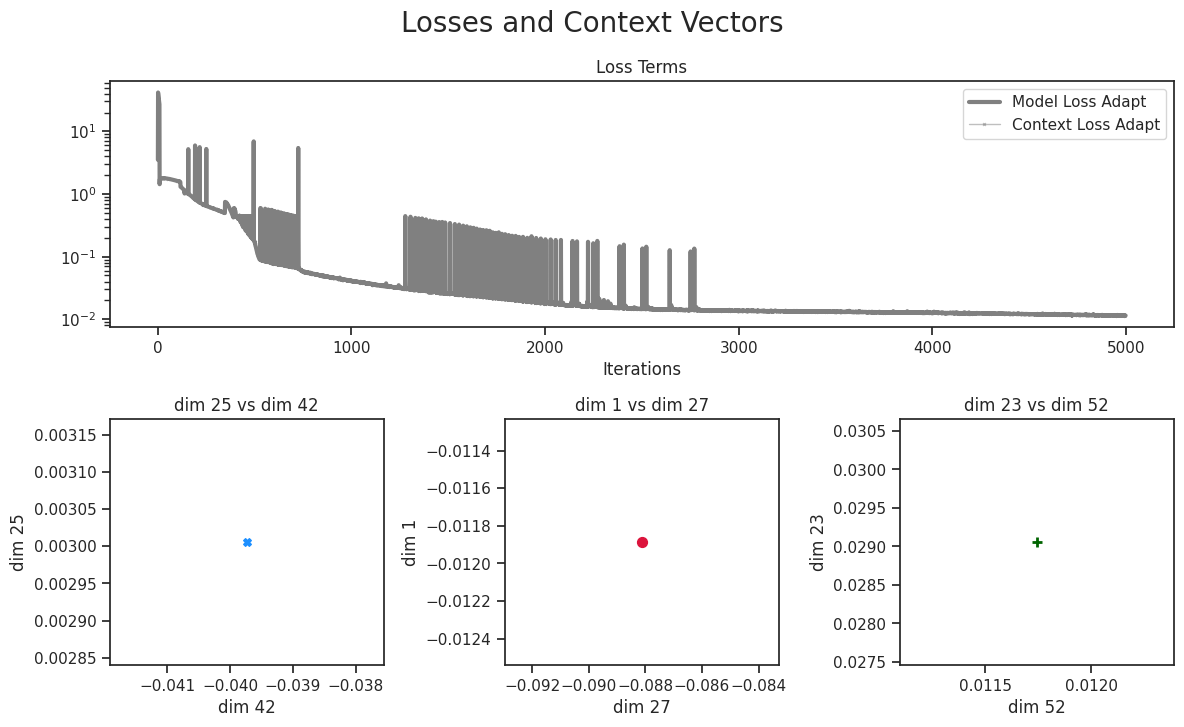

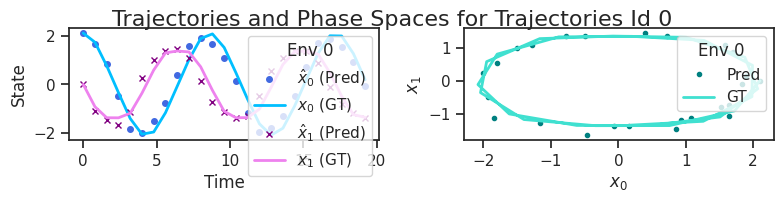

In [ ]:
#%%

visualtester.visualize_artefacts(save_path=adapt_folder+"artefacts_4_4.png", adaptation=True)

visualtester.visualize_dynamics(save_path=adapt_folder+"dynamics_ood_4_4.png",
                                data_loader=adapt_dataloader_test,
                                nb_envs=1,
                                traj=0,
                                share_axes=False,
                                key=test_key)